# Display the Properties of First 20.bin Files


In [3]:
import os
import numpy as np
import open3d as o3d

def load_velodyne_bin(file_path):
    """
    Load a Velodyne .bin file.
    
    Parameters:
        file_path (str): Path to the .bin file.
        
    Returns:
        np.ndarray: Nx4 array with columns (x, y, z, reflectance).
    """
    data = np.fromfile(file_path, dtype=np.float32).reshape(-1, 4)
    return data

def visualize_point_cloud(points):
    """
    Visualize a point cloud using Open3D.
    
    Parameters:
        points (np.ndarray): Nx3 array of point coordinates.
    """
    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(points[:, :3])  # Use only x, y, z for visualization
    o3d.visualization.draw_geometries([point_cloud])

# Directory containing .bin files
directory_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\velodyne"

# Get a list of all .bin files in the directory
bin_files = [f for f in os.listdir(directory_path) if f.endswith('.bin')]

# Process and display properties for the first 20 .bin files
for i, file_name in enumerate(bin_files[:20]):
    file_path = os.path.join(directory_path, file_name)
    velodyne_data = load_velodyne_bin(file_path)
    
    # Print basic properties
    print(f"File {i+1}: {file_name}")
    print(f"Number of points: {velodyne_data.shape[0]}")
    print(f"First point (x, y, z, reflectance): {velodyne_data[0]}")
    print("-" * 50)
    
    # Optional: Uncomment to visualize the point cloud
    # visualize_point_cloud(velodyne_data)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
File 1: 000000.bin
Number of points: 115384
First point (x, y, z, reflectance): [18.324  0.049  0.829  0.   ]
--------------------------------------------------
File 2: 000001.bin
Number of points: 120268
First point (x, y, z, reflectance): [49.52  22.668  2.051  0.   ]
--------------------------------------------------
File 3: 000002.bin
Number of points: 126891
First point (x, y, z, reflectance): [78.779  0.171  2.873  0.   ]
--------------------------------------------------
File 4: 000003.bin
Number of points: 113110
First point (x, y, z, reflectance): [68.127  0.145  2.513  0.   ]
--------------------------------------------------
File 5: 000004.bin
Number of points: 115976
First point (x, y, z, reflectance): [57.657 20.996  2.284  0.   ]
--------------------------------------------------
File 6: 000005.bin
Number 


# Proceesing the first 20 .bin and converting 3d points into 2d flat image.

In [14]:
import numpy as np
import cv2
import os
from tqdm import tqdm  # progress bar

def world2image(x, y, z, image_width, image_height, vertical_fov):
    """
    Convert world coordinates to image coordinates using cylindrical projection.
    """
    theta = np.arctan2(y, x) / np.pi * 180.0 + 180.0
    phi = (np.arctan2(z, np.sqrt(x**2 + y**2)) * 180.0 / np.pi) + (vertical_fov / 2)

    u = int(image_width - (theta / 360.0) * image_width)
    v = int((1 - (phi / vertical_fov)) * image_height)

    return u, v

def process_point_cloud_file(file_path, output_folder, image_width, image_height, vertical_fov, max_dist=35.0):
    # Load point cloud from bin file
    point_cloud = np.fromfile(file_path, dtype=np.float32).reshape(-1, 4)

    # Create an empty image
    img = np.zeros((image_height, image_width, 3), dtype=np.uint8)

    # Add tqdm to display the progress bar
    for point in tqdm(point_cloud, desc=f'Processing {os.path.basename(file_path)}', unit='points'):
        x, y, z, _ = point
        u, v = world2image(x, y, z, image_width, image_height, vertical_fov)

        # Calculate the distance in x, y and z
        d = np.sqrt(x**2 + y**2 + z**2)

        # Normalize the distance
        normalized_dist = d / max_dist

        # Map distance to HSV color
        hue = int(120 * (1 - normalized_dist))  # Hue from green (0) to red (120)
        hue = np.clip(hue, 0, 120)  # Ensure hue is within the valid range
        color = cv2.cvtColor(np.uint8([[[hue, 255, 255]]]), cv2.COLOR_HSV2BGR)[0][0]

        # Check bounds and assign color
        if 0 <= u < image_width and 0 <= v < image_height:
            img[v, u] = color

    # Convert RGB image to BGR (for OpenCV)
    img_cv2 = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Save the image
    base_name = os.path.basename(file_path).replace('.bin', '.png')
    output_path = os.path.join(output_folder, base_name)
    cv2.imwrite(output_path, img_cv2)

def process_point_cloud_folder(input_folder, output_folder):
    # Constants for the image based on Velodyne HDL-64E FOV
    horizontal_fov = 360.0
    vertical_fov = 26.8

    # Determine the image size
    image_width = 2084  # Based on the desired horizontal resolution
    image_height = int(image_width * (vertical_fov / horizontal_fov))  # Maintain aspect ratio based on FOV

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Get the list of `.bin` files and process only the first 20
    file_list = [f for f in os.listdir(input_folder) if f.endswith('.bin')][:20]

    for file_name in tqdm(file_list, desc='Processing files', unit='file'):
        file_path = os.path.join(input_folder, file_name)
        process_point_cloud_file(file_path, output_folder, image_width, image_height, vertical_fov)

# Example usage
input_folder = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\velodyne"
output_folder = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_2D"

process_point_cloud_folder(input_folder, output_folder)


Processing files: 100%|███████████████████████████████████████████████████████████████████████████| 20/20 [05:34<00:00, 16.72s/file]


In [18]:
import numpy as np
import cv2
import os
from tqdm import tqdm  # For progress bar

def world2image(x, y, z, image_width, image_height, vertical_fov):
    """
    Convert world coordinates to image coordinates using cylindrical projection.
    """
    theta = np.arctan2(y, x) / np.pi * 180.0 + 180.0  # Azimuthal angle in degrees
    phi = (np.arctan2(z, np.sqrt(x**2 + y**2)) * 180.0 / np.pi) + (vertical_fov / 2)  # Elevation angle

    u = int(image_width - (theta / 360.0) * image_width)  # Horizontal coordinate
    v = int((1 - (phi / vertical_fov)) * image_height)  # Vertical coordinate

    return u, v

def process_point_cloud_file(file_path, output_folder, image_width, image_height, vertical_fov, max_dist=35.0):
    """
    Process a single point cloud `.bin` file and save the corresponding 2D image.
    """
    # Load the point cloud data
    point_cloud = np.fromfile(file_path, dtype=np.float32).reshape(-1, 4)

    # Create an empty image
    img = np.zeros((image_height, image_width, 3), dtype=np.uint8)

    for point in tqdm(point_cloud, desc=f'Processing {os.path.basename(file_path)}', unit='points'):
        x, y, z, _ = point
        u, v = world2image(x, y, z, image_width, image_height, vertical_fov)

        # Compute the distance of the point
        d = np.sqrt(x**2 + y**2 + z**2)
        normalized_dist = min(d / max_dist, 1.0)  # Normalize distance to [0, 1]

        # Map distance to a hue value (green to red)
        hue = int(120 * (1 - normalized_dist))  # Green (120) to Red (0)
        hue = np.clip(hue, 0, 120)  # Ensure hue stays valid

        # Convert HSV to BGR color
        color = cv2.cvtColor(np.uint8([[[hue, 255, 255]]]), cv2.COLOR_HSV2BGR)[0][0]

        # Assign color to the pixel if coordinates are within bounds
        if 0 <= u < image_width and 0 <= v < image_height:
            img[v, u] = color

    # Save the image
    base_name = os.path.basename(file_path).replace('.bin', '.png')
    output_path = os.path.join(output_folder, base_name)
    cv2.imwrite(output_path, img)

def process_point_cloud_folder(input_folder, output_folder):
    """
    Process a folder of `.bin` point cloud files and save the 2D images.
    """
    # Image parameters
    horizontal_fov = 360.0  # Full horizontal field of view
    vertical_fov = 26.8  # Vertical field of view (based on Velodyne HDL-64E)
    image_width = 2084  # Desired image width
    image_height = int(image_width * (vertical_fov / horizontal_fov))  # Maintain aspect ratio

    # Ensure the output directory exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Get a list of `.bin` files in the input folder
    file_list = [f for f in os.listdir(input_folder) if f.endswith('.bin')][:20]  # Limit to first 20 files

    for file_name in tqdm(file_list, desc='Processing files', unit='file'):
        file_path = os.path.join(input_folder, file_name)
        process_point_cloud_file(file_path, output_folder, image_width, image_height, vertical_fov)

# Example usage
input_folder = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\velodyne"
output_folder = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_2D_20"

process_point_cloud_folder(input_folder, output_folder)


Processing files: 100%|███████████████████████████████████████████████████████████████████████████| 20/20 [06:21<00:00, 19.09s/file]


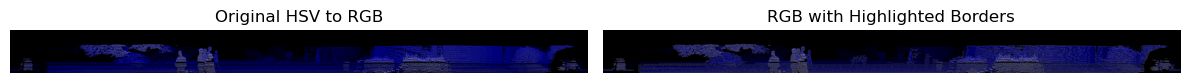

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000000.png


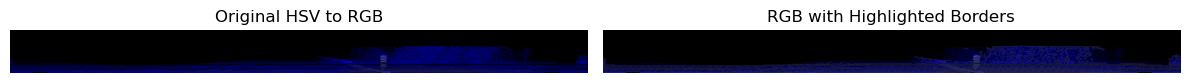

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000001.png


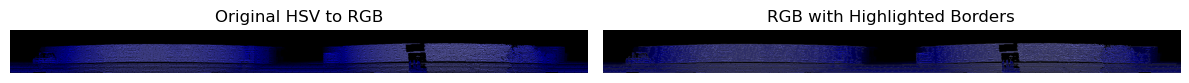

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000002.png


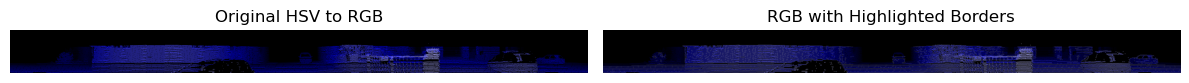

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000003.png


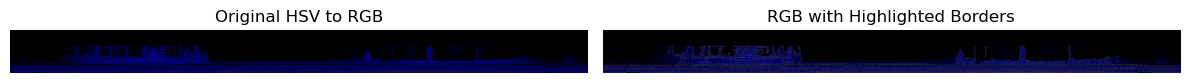

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000004.png


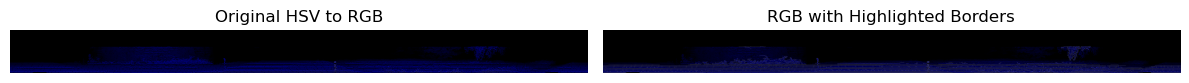

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000005.png


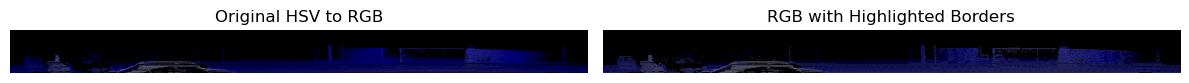

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000006.png


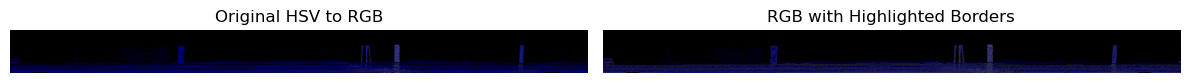

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000007.png


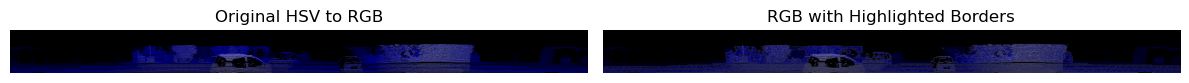

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000008.png


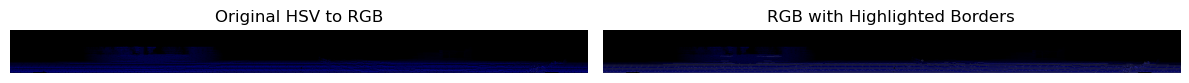

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000009.png


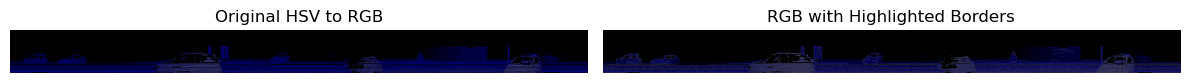

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000010.png


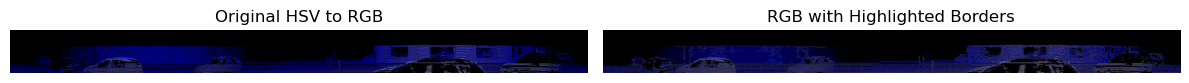

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000011.png


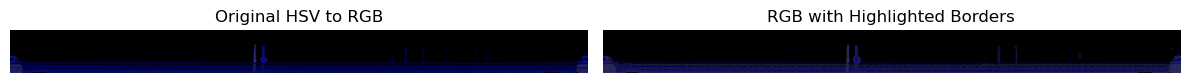

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000012.png


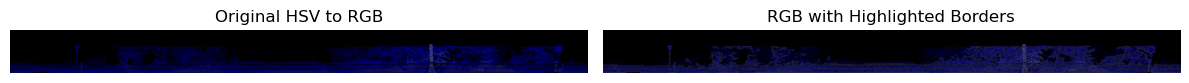

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000013.png


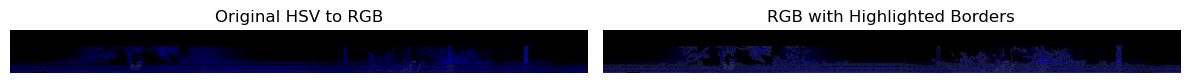

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000014.png


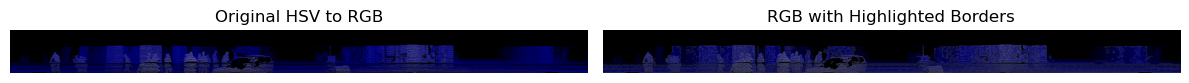

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000015.png


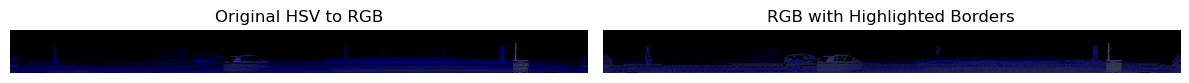

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000016.png


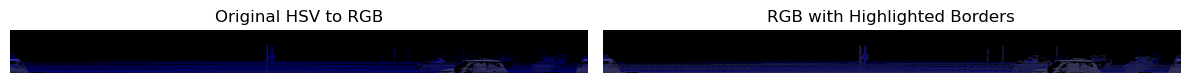

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000017.png


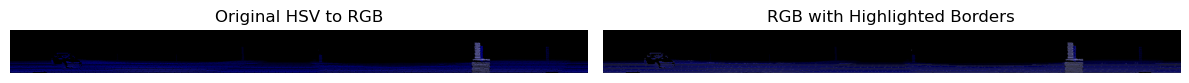

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000018.png


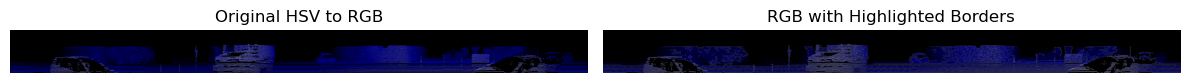

Processed image saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000019.png


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define input and output directories
input_folder = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_2D"
output_folder = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB"

# Ensure the output directory exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Process each image in the input directory
for file_name in os.listdir(input_folder):
    if file_name.endswith(".png"):  # Check if the file is a PNG image
        image_path = os.path.join(input_folder, file_name)  # Full image path
        hsv_image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

        if hsv_image is None:
            print(f"Failed to load image at {image_path}. Please check the path.")
            continue

        # Convert HSV image to RGB
        rgb_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)

        # Enhance borders using edge detection
        # Apply a bilateral filter to reduce noise while keeping edges sharp
        filtered_image = cv2.bilateralFilter(rgb_image, d=9, sigmaColor=75, sigmaSpace=75)

        # Convert the RGB image to grayscale for edge detection
        gray_image = cv2.cvtColor(filtered_image, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray_image, threshold1=50, threshold2=150)

        # Overlay the edges on the original RGB image
        edges_colored = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)  # Convert edges to 3-channel
        highlighted_image = cv2.addWeighted(rgb_image, 0.8, edges_colored, 0.2, 0)

        # Save the processed image
        output_path = os.path.join(output_folder, f"processed_{file_name}")  # Output image path
        cv2.imwrite(output_path, cv2.cvtColor(highlighted_image, cv2.COLOR_RGB2BGR))  # Convert back to BGR for saving

        # Show the original and processed images
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title("Original HSV to RGB")
        plt.imshow(cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB))  # Convert to RGB for Matplotlib
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.title("RGB with Highlighted Borders")
        plt.imshow(cv2.cvtColor(highlighted_image, cv2.COLOR_BGR2RGB))  # Convert to RGB for Matplotlib
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        print(f"Processed image saved to: {output_path}")


In [2]:
pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\dell\appdata\local\temp\pip-req-build-omnc23t9
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\Dell\AppData\Local\Temp\pip-req-build-omnc23t9'


In [3]:
pip show segment-anything

Name: segment-anything
Version: 1.0
Summary: 
Home-page: 
Author: 
Author-email: 
License: 
Location: C:\Users\Dell\anaconda3\Lib\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [1]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
image_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\processed_000019.png"
model_path = r"C:\Users\Dell\Downloads\sam_vit_h_01ec64 (1).pth"

# Load RGB image
rgb_image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB)

# Enhance contrast
lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab_image)
l = cv2.equalizeHist(l)
enhanced_image = cv2.merge((l, a, b))
rgb_image = cv2.cvtColor(enhanced_image, cv2.COLOR_LAB2RGB)

# Load SAM model
sam = sam_model_registry["vit_h"](checkpoint=model_path)
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=64,
    pred_iou_thresh=0.85,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Adjust to include small regions
)

# Generate masks
print("Generating masks...")
masks = mask_generator.generate(rgb_image)

# Visualize masks on image
segmented_image = rgb_image.copy()
for mask in masks:
    color = np.random.randint(0, 255, size=3)
    segmented_image[mask["segmentation"]] = color

# Save and display results
output_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\seg_000019.png"
cv2.imwrite(output_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(rgb_image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Segmented Image")
plt.imshow(segmented_image)
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Segmented image saved to: {output_path}")


C:\Users\Dell\anaconda3\Lib\site-packages\segment_anything\build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


RuntimeError: Error(s) in loading state_dict for Sam:
	Missing key(s) in state_dict: "image_encoder.blocks.12.norm1.weight", "image_encoder.blocks.12.norm1.bias", "image_encoder.blocks.12.attn.rel_pos_h", "image_encoder.blocks.12.attn.rel_pos_w", "image_encoder.blocks.12.attn.qkv.weight", "image_encoder.blocks.12.attn.qkv.bias", "image_encoder.blocks.12.attn.proj.weight", "image_encoder.blocks.12.attn.proj.bias", "image_encoder.blocks.12.norm2.weight", "image_encoder.blocks.12.norm2.bias", "image_encoder.blocks.12.mlp.lin1.weight", "image_encoder.blocks.12.mlp.lin1.bias", "image_encoder.blocks.12.mlp.lin2.weight", "image_encoder.blocks.12.mlp.lin2.bias", "image_encoder.blocks.13.norm1.weight", "image_encoder.blocks.13.norm1.bias", "image_encoder.blocks.13.attn.rel_pos_h", "image_encoder.blocks.13.attn.rel_pos_w", "image_encoder.blocks.13.attn.qkv.weight", "image_encoder.blocks.13.attn.qkv.bias", "image_encoder.blocks.13.attn.proj.weight", "image_encoder.blocks.13.attn.proj.bias", "imag

In [5]:
pip install open3d


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pyntcloud pandas numpy opencv-python


  Obtaining dependency information for pyntcloud from https://files.pythonhosted.org/packages/93/38/8e67f280c571d256fa168cac1dfeec190659cf415dfea0e0771667d22b54/pyntcloud-0.3.1-py2.py3-none-any.whl.metadata
  Using cached pyntcloud-0.3.1-py2.py3-none-any.whl.metadata (4.6 kB)
  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/ec/6c/fab8113424af5049f85717e8e527ca3773299a3c6b02506e66436e19874f/opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata
  Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached pyntcloud-0.3.1-py2.py3-none-any.whl (346 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
Note: you may need to restart the kernel to use updated packages.


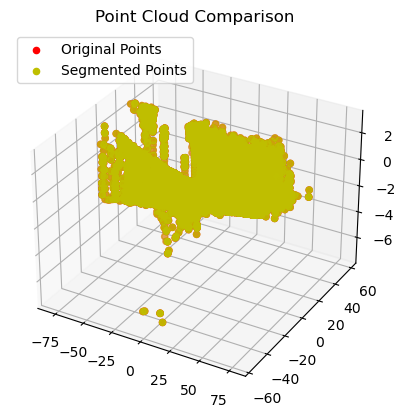

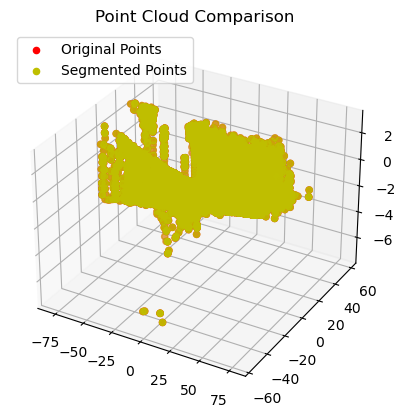

In [3]:
import numpy as np
import struct
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def read_bin_file(bin_file_path):
    """
    Reads the binary file and returns the points (x, y, z, reflectance) as a numpy array.
    """
    points = []
    with open(bin_file_path, 'rb') as file:
        while True:
            point_data = file.read(16)  # 4 * 4 bytes = 16 bytes per point
            if len(point_data) < 16:
                break
            x, y, z, reflectance = struct.unpack('ffff', point_data)
            points.append([x, y, z, reflectance])
    return np.array(points)

def map_2d_to_3d(seg_image, points_3d, image_shape):
    """
    Maps the 2D segmented image to the 3D point cloud based on the corresponding pixel coordinates.
    """
    point_cloud = []
    height, width = image_shape

    for i in range(height):
        for j in range(width):
            label = seg_image[i, j]
            if label > 0:  # Consider non-background labels
                idx = (i * width + j)
                if idx < len(points_3d):
                    x, y, z, reflectance = points_3d[idx]
                    point_cloud.append([x, y, z, reflectance])  # Only include x, y, z, and reflectance
    
    return np.array(point_cloud)

def visualize_point_cloud(original_point_cloud, segmented_point_cloud, title="Point Cloud Comparison"):
    """
    Visualizes the comparison between the original and segmented point clouds.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot original points in red
    ax.scatter(original_point_cloud[:, 0], original_point_cloud[:, 1], original_point_cloud[:, 2], c='r', label='Original Points')

    # Plot segmented points in yellow
    ax.scatter(segmented_point_cloud[:, 0], segmented_point_cloud[:, 1], segmented_point_cloud[:, 2], c='y', label='Segmented Points')

    ax.set_title(title)
    ax.legend(loc='upper left')
    plt.show()

# Example usage
bin_file_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\velodyne\000001.bin"  # Path to the .bin file
seg_image_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\seg_000001.png"  # Path to the segmented image

# Load the segmented image
seg_image = cv2.imread(seg_image_path, cv2.IMREAD_GRAYSCALE)
if seg_image is None:
    raise FileNotFoundError(f"Segmented image not found at {seg_image_path}")

# Read the binary point cloud file
points_3d = read_bin_file(bin_file_path)

# Map the 2D segmented image to 3D points
segmented_point_cloud = map_2d_to_3d(seg_image, points_3d, seg_image.shape)

# Visualize the original and segmented point clouds
visualize_point_cloud(points_3d, segmented_point_cloud)
import numpy as np
import struct
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def read_bin_file(bin_file_path):
    """
    Reads the binary file and returns the points (x, y, z, reflectance) as a numpy array.
    """
    points = []
    with open(bin_file_path, 'rb') as file:
        while True:
            point_data = file.read(16)  # 4 * 4 bytes = 16 bytes per point
            if len(point_data) < 16:
                break
            x, y, z, reflectance = struct.unpack('ffff', point_data)
            points.append([x, y, z, reflectance])
    return np.array(points)

def map_2d_to_3d(seg_image, points_3d, image_shape):
    """
    Maps the 2D segmented image to the 3D point cloud based on the corresponding pixel coordinates.
    """
    point_cloud = []
    height, width = image_shape

    for i in range(height):
        for j in range(width):
            label = seg_image[i, j]
            if label > 0:  # Consider non-background labels
                idx = (i * width + j)
                if idx < len(points_3d):
                    x, y, z, reflectance = points_3d[idx]
                    point_cloud.append([x, y, z, reflectance])  # Only include x, y, z, and reflectance
    
    return np.array(point_cloud)

def visualize_point_cloud(original_point_cloud, segmented_point_cloud, title="Point Cloud Comparison"):
    """
    Visualizes the comparison between the original and segmented point clouds.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot original points in red
    ax.scatter(original_point_cloud[:, 0], original_point_cloud[:, 1], original_point_cloud[:, 2], c='r', label='Original Points')

    # Plot segmented points in yellow
    ax.scatter(segmented_point_cloud[:, 0], segmented_point_cloud[:, 1], segmented_point_cloud[:, 2], c='y', label='Segmented Points')

    ax.set_title(title)
    ax.legend(loc='upper left')
    plt.show()


bin_file_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\velodyne\000001.bin"  # Path to the .bin file
seg_image_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\seg_000001.png"  # Path to the segmented image

# Load the segmented image
seg_image = cv2.imread(seg_image_path, cv2.IMREAD_GRAYSCALE)
if seg_image is None:
    raise FileNotFoundError(f"Segmented image not found at {seg_image_path}")

# Read the binary point cloud file
points_3d = read_bin_file(bin_file_path)

# Map the 2D segmented image to 3D points
segmented_point_cloud = map_2d_to_3d(seg_image, points_3d, seg_image.shape)

# Visualize the original and segmented point clouds
visualize_point_cloud(points_3d, segmented_point_cloud)


In [4]:
import cv2
import numpy as np
import open3d as o3d

def convert_2d_image_to_3d(image_path, ply_file_path):
    """
    Converts a 2D segmented image to a 3D point cloud and saves it as a PLY file.

    Parameters:
    - image_path: str, Path to the 2D segmented image.
    - ply_file_path: str, Path to save the 3D point cloud PLY file.
    """
    # Load the segmented image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Get image dimensions
    height, width, _ = image.shape

    # Initialize points and colors lists
    points = []
    colors = []

    # Assign 3D coordinates and collect points and colors
    for y in range(height):
        for x in range(width):
            r, g, b = image[y, x]
            z = (r + g + b) / 3  # Example depth value (average RGB intensity)
            points.append([x, y, z])
            colors.append([r / 255.0, g / 255.0, b / 255.0])  # Normalize colors to [0, 1]

    # Create Open3D PointCloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Save as PLY file
    o3d.io.write_point_cloud(ply_file_path, pcd)

    # Print total number of points
    print(f"Total number of points: {len(points)}")
    print(f"PLY file saved to: {ply_file_path}")

# Example usage
image_path =   r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\seg_000001.png" # Path to the 2D segmented image
ply_file_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\segmented_0000001.ply"  # Path to save the PLY file

convert_2d_image_to_3d(image_path, ply_file_path) 


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


C:\Users\Dell\AppData\Local\Temp\ipykernel_864\1672230827.py:29: RuntimeWarning: overflow encountered in scalar add
  z = (r + g + b) / 3  # Example depth value (average RGB intensity)


Total number of points: 225720
PLY file saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\segmented_0000001.ply


In [5]:
import struct
import cv2
import numpy as np
import open3d as o3d

def count_points_in_bin(bin_file_path):
    """
    Counts the total number of points in a binary file containing 3D point cloud data.

    Parameters:
    - bin_file_path: str, Path to the binary point cloud file.

    Outputs:
    - Total number of points.
    """
    point_count = 0
    with open(bin_file_path, 'rb') as file:
        while True:
            point_data = file.read(16)  # Each point consists of 16 bytes (4 floats)
            if len(point_data) < 16:
                break
            point_count += 1

    # Print the total number of points
    print(f"Total number of points in bin file: {point_count}")

def convert_2d_image_to_3d(image_path, ply_file_path):
    """
    Converts a 2D segmented image to a 3D point cloud and saves it as a PLY file.

    Parameters:
    - image_path: str, Path to the 2D segmented image.
    - ply_file_path: str, Path to save the 3D point cloud PLY file.
    """
    # Load the segmented image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Get image dimensions
    height, width, _ = image.shape

    # Initialize points and colors lists
    points = []
    colors = []

    # Assign 3D coordinates and collect points and colors
    for y in range(height):
        for x in range(width):
            r, g, b = image[y, x]
            z = (r + g + b) / 3  # Example depth value (average RGB intensity)
            points.append([x, y, z])
            colors.append([r / 255.0, g / 255.0, b / 255.0])  # Normalize colors to [0, 1]

    # Create Open3D PointCloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Save as PLY file
    o3d.io.write_point_cloud(ply_file_path, pcd)

    # Print total number of points
    print(f"Total number of points in 3D point cloud: {len(points)}")
    print(f"PLY file saved to: {ply_file_path}")

# Example usage for counting points in a bin file
bin_file_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\velodyne\000001.bin"  # Path to the binary file
count_points_in_bin(bin_file_path)

# Example usage for converting 2D segmented image to 3D
image_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\Final_20_RGB\seg_000001.png"  # Path to the 2D segmented image
ply_file_path = r"C:\Users\Dell\Downloads\data_object_velodyne_01\training\segmented_0000001.ply"  # Path to save the PLY file
convert_2d_image_to_3d(image_path, ply_file_path)


Total number of points in bin file: 120268


C:\Users\Dell\AppData\Local\Temp\ipykernel_864\56718188.py:51: RuntimeWarning: overflow encountered in scalar add
  z = (r + g + b) / 3  # Example depth value (average RGB intensity)


Total number of points in 3D point cloud: 225720
PLY file saved to: C:\Users\Dell\Downloads\data_object_velodyne_01\training\segmented_0000001.ply
